In [3]:
!pip install -q gdown

# 1) Download the zip
!gdown --fuzzy "https://drive.google.com/file/d/1GrJHVstisCglttDnZdtfc8_rTIeBiKnz/view?usp=sharing" -O /content/archive.zip

# 2) Extract it
import os
import zipfile
import shutil

zip_path = "/content/archive.zip"
extract_path = "/content/dataset"

# Clean old extraction if exists
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction done.")
print("Top-level contents:", os.listdir(extract_path))

Downloading...
From (original): https://drive.google.com/uc?id=1GrJHVstisCglttDnZdtfc8_rTIeBiKnz
From (redirected): https://drive.google.com/uc?id=1GrJHVstisCglttDnZdtfc8_rTIeBiKnz&confirm=t&uuid=1691503a-d254-49e2-9ab1-581c23b5659b
To: /content/archive.zip
100% 2.46G/2.46G [00:32<00:00, 75.7MB/s]
Extraction done.
Top-level contents: ['chest_xray']


In [7]:
import os
import shutil

# Remove annoying Mac folders if they exist anywhere
for root, dirs, files in os.walk("/content/dataset"):
    for d in dirs:
        if d in ["__MACOSX", "_MACOSX"]:
            shutil.rmtree(os.path.join(root, d), ignore_errors=True)

# Auto-detect the real dataset directory
candidate_paths = [
    "/content/dataset",
    "/content/dataset/chest_xray",
    "/content/dataset/chest_xray/chest_xray"
]

DATASET_DIR = None
for path in candidate_paths:
    if os.path.exists(os.path.join(path, "train")) and os.path.exists(os.path.join(path, "test")):
        DATASET_DIR = path
        break

assert DATASET_DIR is not None, "Could not find dataset folder containing train/ and test/"

TRAIN_PATH = os.path.join(DATASET_DIR, "train")
TEST_PATH = os.path.join(DATASET_DIR, "test")

print("Using DATASET_DIR:", DATASET_DIR)
print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)
print("Train classes:", os.listdir(TRAIN_PATH))
print("Test classes:", os.listdir(TEST_PATH))


Using DATASET_DIR: /content/dataset/chest_xray
Train path: /content/dataset/chest_xray/train
Test path: /content/dataset/chest_xray/test
Train classes: ['NORMAL', 'PNEUMONIA']
Test classes: ['NORMAL', 'PNEUMONIA']


# Chest X-Ray Binary Classification (NORMAL vs PNEUMONIA)
## Project: Team Machine Learning - Phase 1 (EfficientNetB0)

This notebook implements a complete binary classification pipeline using **Transfer Learning** with **EfficientNetB0**.

### Objectives:
1. **Data Pipeline:** Load and preprocess Chest X-Ray images.
2. **Model Architecture:** Utilize EfficientNetB0 pre-trained on ImageNet with a custom classification head.
3. **Evaluation:** Comprehensive metrics including F1-Score and ROC-AUC.
4. **Ensemble Readiness:** Export prediction probabilities for future soft-voting ensembles.

**Note:** This project focuses on **Classification**, not Image Segmentation.

In [8]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils import class_weight

# --- Reproducibility ---
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# --- Configuration ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 16  # Reduced for stability
CHANNELS = 3
# DATASET_DIR will be set automatically by the previous cell
MODEL_SAVE_PATH = 'best_efficientnet_model.keras'
MODEL_SAVE_PATH = 'best_efficientnet_model.keras'

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


## 1. Data Acquisition and Cleaning
We use `gdown` to retrieve the dataset. We then extract and clean any system-generated folders like `__MACOSX` which can interfere with Keras generators.

In [9]:
TRAIN_PATH = os.path.join(DATASET_DIR, 'train')
TEST_PATH = os.path.join(DATASET_DIR, 'test')

# Quick Path Verification
for path in [TRAIN_PATH, TEST_PATH]:
    if os.path.exists(path):
        print(f"Found: {path}")
        print(f"Classes: {os.listdir(path)}")
    else:
        print(f"CRITICAL: Path {path} not found. Please ensure extraction was successful.")

print("\nDataset Directory Contents:")
!ls {DATASET_DIR}

Found: /content/dataset/chest_xray/train
Classes: ['NORMAL', 'PNEUMONIA']
Found: /content/dataset/chest_xray/test
Classes: ['NORMAL', 'PNEUMONIA']

Dataset Directory Contents:
chest_xray  test  train  val


### Note on Validation Strategy
The original `val` folder in many Chest X-Ray datasets contains very few samples (often <20). This is statistically unreliable for monitoring convergence. We will perform a **validation split** from the `train` folder (e.g., 20%) to ensure a representative validation set while keeping the `test` folder completely separate for final evaluation.

In [10]:
# Data Augmentation for Training (EfficientNetB0 handles rescaling internally)
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False, # Standard for Medical X-Rays
    validation_split=0.2
)

# No augmentation for testing
test_datagen = ImageDataGenerator()

print("Loading Training Set:")
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=SEED
)

print("Loading Validation Set:")
val_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=SEED
)

print("Loading Test Set:")
test_generator = test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False # REQUIRED for CSV alignment
)

# Compute Class Weights
labels = train_generator.classes
weights = class_weight.compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weights = {i: weights[i] for i in range(len(weights))}

print(f"\nClass Indices: {train_generator.class_indices}")
print(f"Class Weights: {class_weights}")

Loading Training Set:
Found 4173 images belonging to 2 classes.
Loading Validation Set:
Found 1043 images belonging to 2 classes.
Loading Test Set:
Found 624 images belonging to 2 classes.

Class Indices: {'NORMAL': 0, 'PNEUMONIA': 1}
Class Weights: {0: np.float64(1.9445479962721341), 1: np.float64(0.6730645161290323)}


## 2. Model Architecture
We use **EfficientNetB0** with ImageNet weights. EfficientNet is chosen for its superior parameter efficiency compared to older architectures like ResNet.

In [11]:
def build_model():
    # EfficientNetB0 with frozen ImageNet weights
    base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3))
    base_model.trainable = False

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model = build_model()
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## 3. Training and Evaluation
We use `EarlyStopping` to prevent overfitting and `ModelCheckpoint` to save the best version of our weights.

In [12]:
checkpoint_cb = callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor='val_accuracy')
early_stop_cb = callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')
reduce_lr_cb = callbacks.ReduceLROnPlateau(factor=0.2, patience=3, monitor='val_loss')

# Practical number of epochs for initial run
EPOCHS = 8

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb]
)

Epoch 1/8
261/261 ━━━━━━━━━━━━━━━━━━━━ 437s 2s/step - accuracy: 0.9034 - auc: 0.9670 - loss: 0.2489 - val_accuracy: 0.9415 - val_auc: 0.9887 - val_loss: 0.1390 - learning_rate: 0.0010
Epoch 2/8
261/261 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.9245 - auc: 0.9775 - loss: 0.1870 - val_accuracy: 0.9118 - val_auc: 0.9879 - val_loss: 0.2084 - learning_rate: 0.0010
Epoch 3/8
261/261 ━━━━━━━━━━━━━━━━━━━━ 396s 2s/step - accuracy: 0.9341 - auc: 0.9820 - loss: 0.1631 - val_accuracy: 0.9300 - val_auc: 0.9907 - val_loss: 0.1695 - learning_rate: 0.0010
Epoch 4/8
261/261 ━━━━━━━━━━━━━━━━━━━━ 385s 1s/step - accuracy: 0.9389 - auc: 0.9852 - loss: 0.1541 - val_accuracy: 0.9425 - val_auc: 0.9918 - val_loss: 0.1405 - learning_rate: 0.0010
Epoch 5/8
261/261 ━━━━━━━━━━━━━━━━━━━━ 391s 1s/step - accuracy: 0.9480 - auc: 0.9889 - loss: 0.1262 - val_accuracy: 0.9473 - val_auc: 0.9927 - val_loss: 0.1328 - learning_rate: 2.0000e-04
Epoch 6/8
261/261 ━━━━━━━━━━━━━━━━━━━━ 398s 2s/step - accuracy: 0.9463 - auc

## 4. Final Evaluation & Ensemble Export
To perform a **Soft-Voting Ensemble** in the future, we must save the raw sigmoid probabilities (`prob_pneumonia`). Standardizing the test set format across all team members' notebooks (DenseNet, Swin, etc.) is vital for merging results.

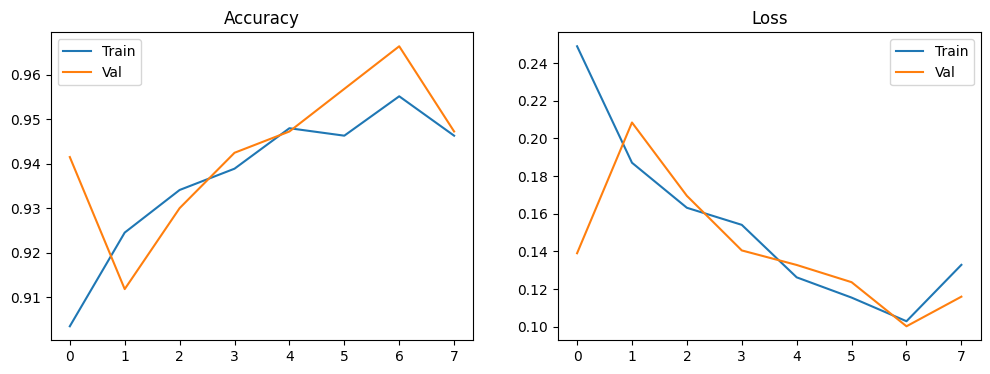

Generating predictions on test set...
39/39 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step

--- Classification Report ---
              precision    recall  f1-score   support

      NORMAL       0.90      0.84      0.87       234
   PNEUMONIA       0.91      0.94      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.89      0.90       624
weighted avg       0.90      0.90      0.90       624

ROC-AUC Score: 0.9704

File saved: efficientnet_test_predictions.csv


In [13]:
# 1. Plot Training History
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['accuracy'], label='Train')
ax[0].plot(history.history['val_accuracy'], label='Val')
ax[0].set_title('Accuracy')
ax[0].legend()

ax[1].plot(history.history['loss'], label='Train')
ax[1].plot(history.history['val_loss'], label='Val')
ax[1].set_title('Loss')
ax[1].legend()
plt.show()

# 2. Load and Evaluate Best Model
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)

print("Generating predictions on test set...")
preds_prob = best_model.predict(test_generator).flatten()
preds_class = (preds_prob > 0.5).astype(int)
true_labels = test_generator.classes

# Metrics
print("\n--- Classification Report ---")
print(classification_report(true_labels, preds_class, target_names=list(test_generator.class_indices.keys())))
print(f"ROC-AUC Score: {roc_auc_score(true_labels, preds_prob):.4f}")

# 3. Export CSV for Ensemble
results_df = pd.DataFrame({
    'filename': test_generator.filenames,
    'true_label': true_labels,
    'pred_label': preds_class,
    'prob_pneumonia': preds_prob
})

results_df.to_csv('efficientnet_test_predictions.csv', index=False)
print("\nFile saved: efficientnet_test_predictions.csv")